[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eveningsilverfox/ML_tutorials/blob/main/09_tutorial_VAE.ipynb)

# Tutorial: Autoencoders with JAX

An **autoencoder** is a neural network that learns to compress data $x$ into a low-dimensional latent vector $z$, and then to reconstruct $x$ from $z$:

$$ x \;\xrightarrow{\;\text{encoder}\;}\; z \;\xrightarrow{\;\text{decoder}\;}\; \hat x \,. $$

Trained to minimise $\|x - \hat x\|^2$, the encoder is forced to keep only the information needed to reconstruct $x$. The bottleneck $z$ becomes a compact, useful representation of the data. We will see that, it often discovers genuinely meaningful structure, with a very interesting example of discovering the order parameter of a phase transition.

This notebook builds a plain autoencoder from scratch in **JAX** (no flax) and explores it through three exercises:

1. **Capacity sweep** &mdash; how does the reconstruction error depend on the size of the bottleneck, and does it reveal the *intrinsic dimensionality* of the data?
2. **Latent-space interpolation** &mdash; what does it look like to walk in a straight line in latent space?
3. **Detecting a phase transition** &mdash; can an autoencoder *discover* the order parameter of the 2-D Ising model without ever being told there is a phase transition?

## 1. Setup

##### Colab setup

On a fresh Google Colab runtime, JAX, NumPy, Matplotlib and IPython are pre-installed, but `optax` is not. The cell below installs it on first run and is a no-op afterwards, so it is also safe to run locally.

In [ ]:
# Colab / fresh-environment setup. Safe to re-run.
try:
    import optax 
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optax'])
    import optax 

In [1]:
import jax
import jax.numpy as jnp
import optax
import functools

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

## 2. Building the autoencoder

We store the parameters of a multilayer perceptron (MLP) as a plain Python list of `(W, b)` tuples,

```python
params = [(W1, b1), (W2, b2), ...]
```

JAX is perfectly happy to differentiate through such nested "PyTrees", and `optax` can apply updates to them with `optax.apply_updates`.

In [ ]:
def init_mlp(key, layer_sizes, scale=0.1):
    """Random parameters for an MLP with layout `layer_sizes`.

    Returns a list [(W1, b1), (W2, b2), ...], one (W, b) per layer.
    """
    params = []
    keys = jax.random.split(key, len(layer_sizes) - 1)
    # Say layer_sizes = [2, 32, 32, 4] (the encoder from Example 1). That describes a network with three layers:
    # layer	input dim output dim
    # 1 	2         32
    # 2 	32        32
    # 3 	32	      4
    # layer_sizes[:-1] = [2, 32, 32]: input sizes.
    # layer_sizes[1:] = [32, 32, 4]: output sizes.
    # zip pairs up elements from several iterables position-by-position, 
    # yielding tuples until the shortest one runs out.
    # list(zip([1, 2, 3], ['a', 'b', 'c']))
    # -> [(1, 'a'), (2, 'b'), (3, 'c')]
    for k, n_in, n_out in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
        W = scale * jax.random.normal(k, (n_in, n_out))
        b = jnp.zeros((n_out,))
        params.append((W, b)) # list of tuple of jnp array 
        # PyTree node types: list, tuple, dict
        # print( jax.tree.leaves(params) )
    # for ij in range(len(layer_sizes)-1):
    #     key, key1 = jax.random.split(key)
    #     W = jax.random.normal(key1, (layer_sizes[ij],layer_sizes[ij+1]))
    #     b = jnp.zeros((layer_sizes[ij+1],))
    #     params.append((W, b))
    return params

def mlp_forward(params, x, final_activation=None):
    """Run an MLP with tanh hidden activations.

    `x` can be a single vector or a batch with shape (batch, n_in).
    `final_activation` is an optional callable applied to the output layer.
    e.g. final_activation=jnp.tanh, or final_activation=jax.nn.sigmoid, ...
    """
    h = x
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    out = h @ W + b
    if final_activation is not None:
        out = final_activation(out)
    # h = x
    # for ij in range(len(params)-1):
    #     W, b = params[ij]
    #     h = jnp.tanh(h @ W + b)
    # W, b = params[-1]
    # out = h @ W + b 
    # if final_activation is not None:
    #     out = final_activation(out)   
    return out

The encoder and decoder are then nothing more than two MLPs. The encoder maps data $x$ to a latent vector $z$; the decoder maps $z$ back to data space. The loss is the mean squared reconstruction error,

$$ \mathcal L(\theta) \;=\; \frac{1}{N} \sum_{i=1}^N \|x_i - \mathrm{decoder}(\mathrm{encoder}(x_i))\|^2. $$

In [ ]:
def encoder(params, x):
    return mlp_forward(params, x)


def decoder(params, z, final_activation=None):
    return mlp_forward(params, z, final_activation=final_activation)


def ae_loss(params, x, final_activation=None):
    enc_params, dec_params = params # Expects params = (enc_params, dec_params), a tuple of two lists.
    z = encoder(enc_params, x)
    x_recon = decoder(dec_params, z, final_activation=final_activation)
    return jnp.mean((x_recon - x) ** 2)

We wrap one gradient step in `jax.jit` so it compiles to fast machine code. The factory `make_train_step` lets us create a step function that is bound to a specific optimizer and (optionally) a specific output activation.

In [4]:
@functools.partial(jax.jit, static_argnums=(3, 4))
def train_step0(params, opt_state, x, optimizer, final_activation):
    """
    One gradient step on a minibatch x.
    Optimizer and final_activation don't exist yet at definition time.
    Have to tell jax to treat them as compite time constants.
    """
    loss, grads = jax.value_and_grad(ae_loss)(params, x, final_activation)  # loss and grads of ae_loss
    updates, opt_state = optimizer.update(grads, opt_state)  # delta params, optimizer state (momentum, ...)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss  # optimizer state has to be carrier over steps

def train_ae(
    X, latent_dim, key, 
    hidden=[64, 32], n_steps=4000, batch_size=128, lr=2e-3, 
    final_activation=None, print_every = 1000
):
    """Train an autoencoder on `X` with the given bottleneck size (latent_dim).

    The encoder layout is [data_dim, *hidden, latent_dim] and the decoder mirrors it.
    Returns trained (enc_params, dec_params) and the per-step loss history.
    """
    data_dim = X.shape[1] # X.shape = (n_samples, data_dim)
    rng, enc_key, dec_key = jax.random.split(key, 3)
    enc_params = init_mlp(enc_key, [data_dim, *hidden, latent_dim])
    dec_params = init_mlp(dec_key, [latent_dim, *reversed(hidden), data_dim])
    params = (enc_params, dec_params)
    # params is a tuple of two lists: the first element is the encoder's [(W,b), ...] and the second is the decoder's. 

    opt = optax.adam(lr) # adam optimizer object
    opt_state = opt.init(params) # Initialize adam optimizer

    @jax.jit
    def train_step(params, opt_state, x):
        """ 
        One gradient step on a minibatch x.
        Optimizer and final_activation already defined and are thus treated 
        as static (compile-time constants).
        """
        loss, grads = jax.value_and_grad(ae_loss)(params, x, final_activation=final_activation)  # closes over both
        updates, opt_state = opt.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    losses = []
    n_data = X.shape[0]
    for s in range(n_steps):
        #Choose 
        rng, batch_key = jax.random.split(rng)
        idx = jax.random.randint(batch_key, (batch_size,), 0, n_data)
        params, opt_state, loss = train_step(params, opt_state, X[idx])
        losses.append(float(loss)) # loss is jax array!
        if (s % print_every == 0 or s == n_steps - 1):
            print(f'step {s:5d}  loss={loss:.6f}')
    return params, losses

---
## 3. Exercise: capacity sweep: finding the intrinsic dimension

Our first question is the most fundamental one you can ask about an autoencoder: **how small can the bottleneck be?**

If the data is generated from a few independent factors, an autoencoder with a bottleneck *as small as the number of factors* should be able to reconstruct it almost perfectly. With fewer bottleneck units it must throw information away and reconstruction quality drops; with more units it cannot do dramatically better. So we expect that the curve of reconstruction loss vs. `latent_dim` should show around the intrinsic dimension of the data.

(Strictly, this is expected for *linear* autoencoders, which mirrors the principal-component analysis. A *non-linear* autoencoder will likely exhibit some deviations.)

We will use a toy dataset where we know the answer: greyscale images of an **anisotropic Gaussian blob** with four independent factors of variation: the centre $(c_x, c_y)$ and the two widths $(\sigma_x, \sigma_y)$. Our expectation: the loss should drop sharply around `latent_dim=4` and then flatten.

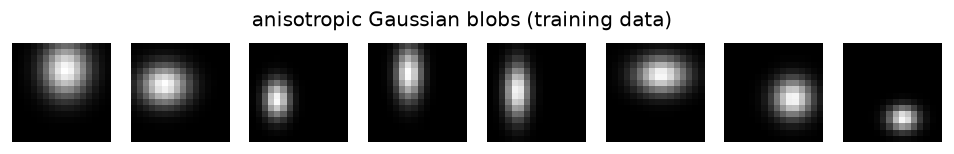

In [5]:
IMG_WIDTH = 16 # (IMG_WIDTH, IMG_WIDTH) image

def make_aniso_blobs(n_samples, key, n_pix=IMG_WIDTH):
    """
    Make `n_samples` images of an anisotropic 2D Gaussian blob,
    constructed out of two independent 1D Gaussians, one for each exis.

    Four underlying factors per image: centre (cx, cy) and widths (sx, sy).
    Returns flattened pixel values (in [0, 1]) and the factor values.
    """
    k_cx, k_cy, k_sx, k_sy = jax.random.split(key, 4)
    # centre coordinates
    cx = jax.random.uniform(k_cx, (n_samples,), minval=3.0,  maxval=n_pix - 4.0)
    cy = jax.random.uniform(k_cy, (n_samples,), minval=3.0,  maxval=n_pix - 4.0)
    # standard deviations
    sx = jax.random.uniform(k_sx, (n_samples,), minval=1.0,  maxval=3.0)
    sy = jax.random.uniform(k_sy, (n_samples,), minval=1.0,  maxval=3.0)
    
    # 1D pixel grid
    g  = jnp.arange(n_pix)
    # Gaussian along x
    # g[None, :] ~ (1, n_pix), broadcast over all samples
    # cx[:, None] ~ (n_samples, 1), broadcast over all 1D pixels
    # sx[:, None] ~ (n_samples, 1), broadcast over all 1D pixels
    # g[None, :] - cx[:, None] = g_j
    gx = jnp.exp(-0.5 * ((g[None, :] - cx[:, None]) / sx[:, None]) ** 2) 
    # Gaussian along y
    gy = jnp.exp(-0.5 * ((g[None, :] - cy[:, None]) / sy[:, None]) ** 2)
    # Convention: first index is the row [run vertically (the y-direction)] 
    # and the second is the column [run horizontally (the x-direction)].
    # want img ~ (n_samples, n_y=n_pix, n_x=n_pix)
    # gy[:, :, None] ~ (n_samples, n_y=n_pix, 1)
    # gx[:, None, :] ~ (n_samples, 1, n_x=n_pix)
    img = gy[:, :, None] * gx[:, None, :]
    factors = jnp.stack([cx, cy, sx, sy], axis=-1) # (nsamples, 4)
    return img.reshape(n_samples, n_pix * n_pix), factors # flattened image, Gaussian params

rng = jax.random.key(0)
# Training set
rng, sub_train = jax.random.split(rng)
X_blob, _ = make_aniso_blobs(4000, sub_train)
# Testing set
rng, sub_test = jax.random.split(rng)
X_test, _ = make_aniso_blobs(500, sub_test)

# Show eight examples so we can see what the data looks like.
fig, axes = plt.subplots(1, 8, figsize=(10, 1.4))
for i, ax in enumerate(axes):
    ax.imshow(np.asarray(X_blob[i]).reshape(IMG_WIDTH, IMG_WIDTH), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('anisotropic Gaussian blobs (training data)')
plt.show()

Now train autoencoders with bottleneck sizes spanning two orders of magnitude. For each we record the held-out reconstruction loss (evaluated on `X_test`, not seen during training) and keep the trained parameters around for visualization.

In [ ]:
latent_dims = [1, 2, 4, 8, 16, 32, 64]
test_losses = []
trained_params = {} # Store as a dict {key=latent_dim, value=params for latent_dim}

rng = jax.random.key(1)
for d in latent_dims:
    rng, sub = jax.random.split(rng)
    params, _ = train_ae(
        X_blob, latent_dim=d, key=sub,
        hidden=(128, 128), n_steps=5000, lr=2e-3,
    )

    # Testing set loss
    enc_p, dec_p = params
    X_test_recon = decoder(dec_p, encoder(enc_p, X_test))
    test_loss = float(jnp.mean((X_test_recon - X_test) ** 2))
    test_losses.append(test_loss)
    trained_params[d] = params # {d, params for d}
    print(f'latent_dim={d:2d}   held-out reconstruction loss = {test_loss:7.6f}')

step     0  loss=0.045901
step  1000  loss=0.022021
step  2000  loss=0.014223
step  3000  loss=0.013223
step  4000  loss=0.012333
step  4999  loss=0.011817
latent_dim= 1   held-out reconstruction loss = 0.011874
step     0  loss=0.052218
step  1000  loss=0.007143
step  2000  loss=0.005925
step  3000  loss=0.005548
step  4000  loss=0.005231
step  4999  loss=0.004887
latent_dim= 2   held-out reconstruction loss = 0.005387
step     0  loss=0.054795
step  1000  loss=0.002859
step  2000  loss=0.001627
step  3000  loss=0.001001
step  4000  loss=0.000774
step  4999  loss=0.000634
latent_dim= 4   held-out reconstruction loss = 0.000736
step     0  loss=0.068933
step  1000  loss=0.001497
step  2000  loss=0.000588
step  3000  loss=0.000356
step  4000  loss=0.000249
step  4999  loss=0.000220
latent_dim= 8   held-out reconstruction loss = 0.000241
step     0  loss=0.090050
step  1000  loss=0.001048
step  2000  loss=0.000457
step  3000  loss=0.000272
step  4000  loss=0.000199
step  4999  loss=0.000

The reconstruction-loss curve and a side-by-side gallery of reconstructions at different bottleneck sizes.

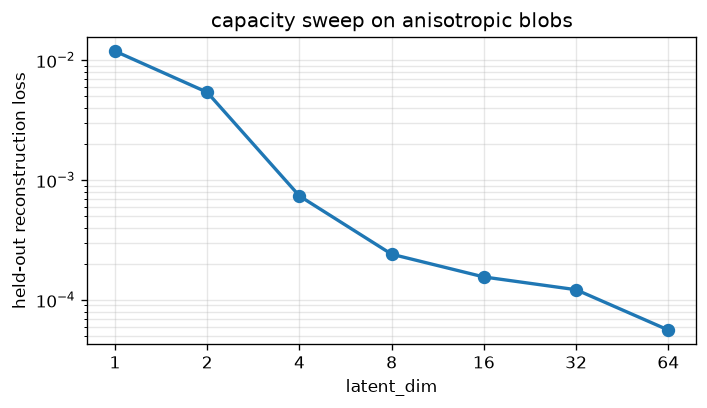

In [7]:
# Reconstruction loss vs. latent_dim
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(latent_dims, test_losses, 'o-', color='C0', linewidth=2, markersize=7)
ax.set_xscale('log', base=2)
ax.set_xticks(latent_dims); ax.set_xticklabels([str(d) for d in latent_dims])
ax.set_xlabel('latent_dim'); ax.set_ylabel('held-out reconstruction loss')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.set_title('capacity sweep on anisotropic blobs')
plt.tight_layout()
plt.show()

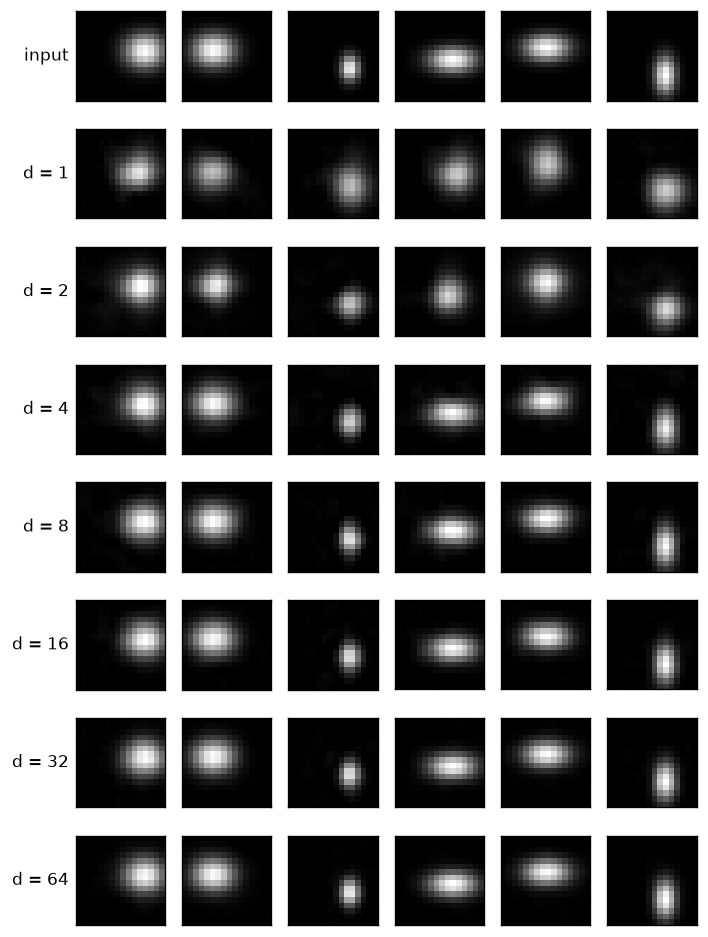

In [8]:
# Reconstruction gallery: input on top, then one row per latent_dim.
k_show = jax.random.key(1)
n_show = 6
show_ind = jax.random.randint(k_show, (n_show,), minval=0, maxval=500)
fig, axes = plt.subplots(len(latent_dims) + 1, n_show, figsize=(n_show * 1.0, (len(latent_dims) + 1) * 1.0))

for j in range(n_show):
    axes[0, j].imshow(np.asarray(X_test[show_ind[j]]).reshape(IMG_WIDTH, IMG_WIDTH), cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_xticks([])
    axes[0, j].set_yticks([])
axes[0, 0].set_ylabel('input', fontsize=10, rotation=0, ha='right', va='center')

for i, d in enumerate(latent_dims):
    enc_p, dec_p = trained_params[d]
    X_test_recon = decoder(dec_p, encoder(enc_p, X_test[show_ind]))
    for j in range(n_show):
        axes[i + 1, j].imshow(np.asarray(X_test_recon[j]).reshape(IMG_WIDTH, IMG_WIDTH), cmap='gray', vmin=0, vmax=1)
        axes[i + 1, j].set_xticks([])
        axes[i + 1, j].set_yticks([])
    axes[i + 1, 0].set_ylabel(f'd = {d}', fontsize=10, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

Read these two figures together.

**The curve.** The held-out reconstruction loss drops by more than an order of magnitude from `latent_dim = 1` to `latent_dim = 4`, the four factors of variation are being captured one at a time. Beyond `d = 4` the loss continues to fall, but much more slowly. For large `d >> 8` the curve is essentially flat, extra bottleneck units not crucial.

**The gallery.** With fewer that `latent_dim = 4` bottleneck unit, the autoencoder does not pass enough information to the decoder to reconstruct the image, and all reconstructions look like a blurred average of the data. With `latent_dim = 4` or more units the reconstructions sharpen up dramatically. Eventually, the reconstructions are visually almost indistinguishable from the inputs.

Thus, autoencoder can *discover* how many degrees of freedom your data really has, without you having to tell it.

---
## 3'. Exercise: what did each latent dimension learn?

The capacity sweep tells us the bottleneck *size* that is sufficient, but not *what* each latent unit actually encodes. For the `d = 4` model we know the four ground-truth factors: blob centre $(c_x, c_y)$ and widths $(\sigma_x, \sigma_y)$. If the autoencoder has genuinely discovered these factors, each latent dimension should correlate strongly with exactly one of them and weakly with the rest.

Encode the test set and make a $4 \times 4$ scatter-plot grid: rows = latent dimensions $z_0, \dots, z_3$, columns = true factors $c_x, c_y, \sigma_x, \sigma_y$. Annotate each panel with the Pearson correlation $r$. A good solution shows four panels with $|r| \approx 1$ (one per row) and the remaining twelve near zero.

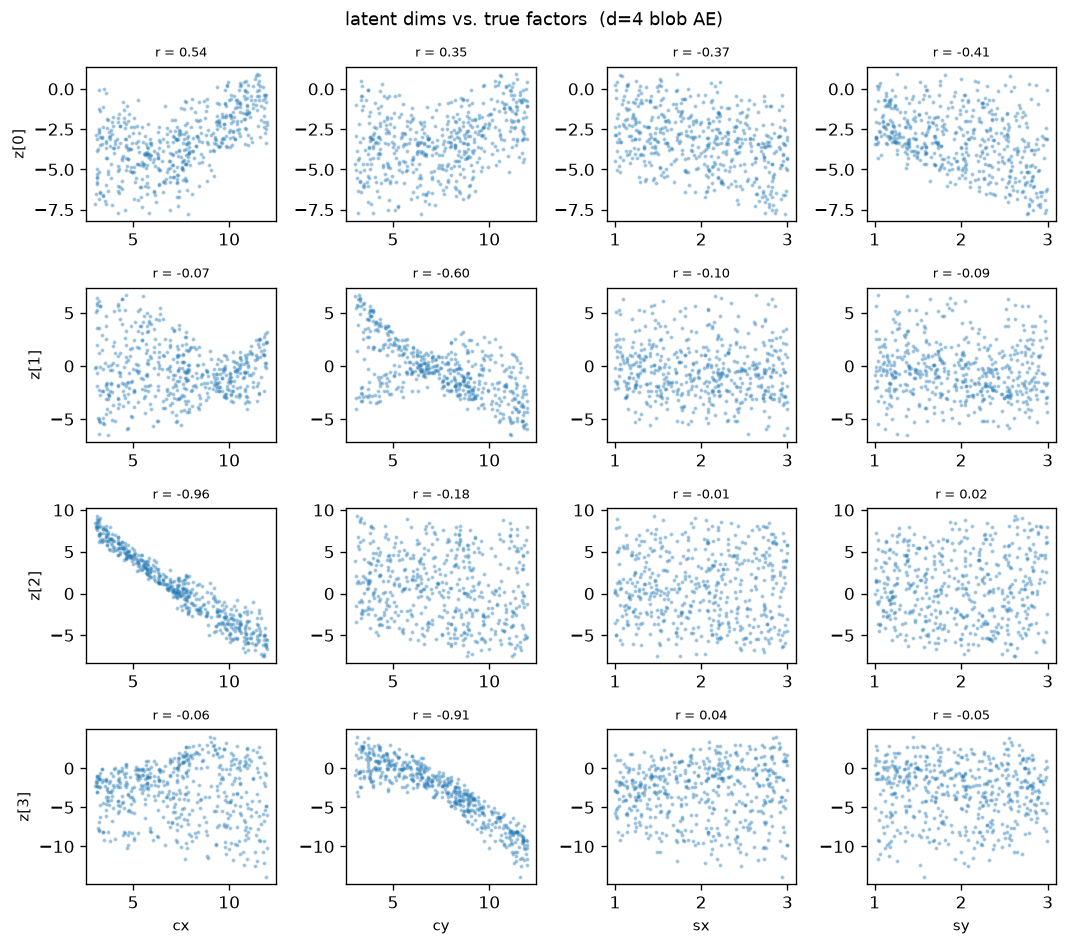

In [ ]:
# Same key as before, same images, so factors align with X_test.
_, factors_test = make_aniso_blobs(500, sub_test)   # (500, 4)
enc_p, _ = trained_params[4]
Z_test = np.asarray(encoder(enc_p, X_test))         # (500, 4)

factor_names = ['cx', 'cy', 'sx', 'sy']
fig, axes = plt.subplots(4, 4, figsize=(9, 8))
for i in range(4):          # latent dim (rows)
    for j in range(4):      # true factor (cols)
        r = np.corrcoef(np.asarray(factors_test[:, j]), Z_test[:, i])[0, 1]
        axes[i, j].scatter(np.asarray(factors_test[:, j]), Z_test[:, i],
                           s=2, alpha=0.3, color='C0')
        axes[i, j].set_title(f'r = {r:.2f}', fontsize=8)
        if i == 3:
            axes[i, j].set_xlabel(factor_names[j], fontsize=9)
        if j == 0:
            axes[i, j].set_ylabel(f'z[{i}]', fontsize=9)
plt.suptitle('latent dims vs. true factors  (d=4 blob AE)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Exercise: interpolating in pixel space vs. latent space

Pick two images $x_a$ and $x_b$. We compare two ways of forming intermediate images.

1. **Pixel-space interpolation**: mix the two images directly:
   $$ x_\alpha \;=\; (1 - \alpha)\,x_a + \alpha\,x_b. $$
2. **Latent-space interpolation**: encode, interpolate in latent space, and decode:
   $$ x_\alpha \;=\; \text{decoder}\big((1 - \alpha)\,\text{encoder}(x_a) + \alpha\,\text{encoder}(x_b)\big). $$

If the autoencoder has truly learned the underlying factors of variation of the data, i.e., it has learned a ``latent_dim``-parameter family of mappings, varying the latent variable should ``transport" the first image to the second. The pixel-space row, by contrast, simply fades one image into the other. We will use the `latent_dim = 4` blob autoencoder we already trained in &sect;3.

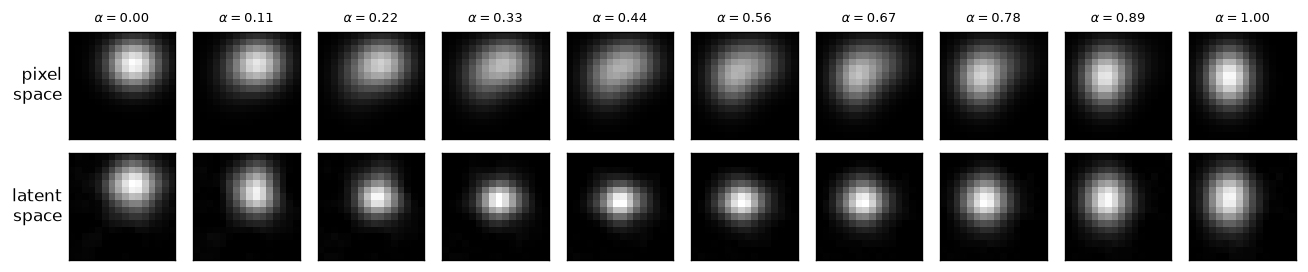

In [ ]:
rng, sub = jax.random.split(rng)
X_two, _ = make_aniso_blobs(2, sub)

enc_p, dec_p = trained_params[4]  # reuse the d=4 model from the capacity sweep
# X_two[0:1]~(1,IMG_WIDTH**2) instead of X_two[0]~(,IMG_WIDTH**2)
# because we want z_a~(1,4), as alphas~(n_interp,1). 
# So alphas * z_b ~ (n_interp,1)*(1,4) = (n_interp,4)
z_a = encoder(enc_p, X_two[0:1]) 
z_b = encoder(enc_p, X_two[1:2])

n_interp = 10
alphas = jnp.linspace(0.0, 1.0, n_interp)[:, None] # Interpolating coefficient

# Same logic as above, need the singleton dimension for broadcasting
# alphas * X_two[1:2] ~ (n_interp,1)*(1,IMG_WIDTH**2) = (n_interp,IMG_WIDTH**2)
X_pix = (1.0 - alphas) * X_two[0:1] + alphas * X_two[1:2]   # pixel-space interpolation
Z     = (1.0 - alphas) * z_a + alphas * z_b
X_lat = decoder(dec_p, Z)                                     # latent-space interpolation

# ---OR non-vectorised---
za = encoder(enc_p, X_two[0])
zb = encoder(enc_p, X_two[1])
n_interp = 10
alphas = jnp.linspace(0.0, 1.0, n_interp)
X_pix = jnp.zeros((n_interp, IMG_WIDTH**2))
X_lat = jnp.zeros((n_interp, IMG_WIDTH**2))
for gh in range(n_interp):
    X_pix = X_pix.at[gh].set((1 - alphas[gh]) * X_two[0] + alphas[gh] * X_two[1])
    z = (1 - alphas[gh]) * za + alphas[gh] * zb
    X_lat = X_lat.at[gh].set(decoder(dec_p, z))

fig, axes = plt.subplots(2, n_interp, figsize=(n_interp * 1.1, 2.4))
for i in range(n_interp):
    axes[0, i].imshow(np.asarray(X_pix[i]).reshape(IMG_WIDTH, IMG_WIDTH), cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(np.asarray(X_lat[i]).reshape(IMG_WIDTH, IMG_WIDTH), cmap='gray', vmin=0, vmax=1)
    for r in (0, 1):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
    axes[0, i].set_title(fr'$\alpha = {float(alphas[i, 0]):.2f}$', fontsize=8)
axes[0, 0].set_ylabel('pixel\nspace',  fontsize=10, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('latent\nspace', fontsize=10, rotation=0, ha='right', va='center')
plt.tight_layout()
plt.show()

Look at the difference between the two rows.

**Top (pixel space).** The intermediate images are double exposures: you can see *both* blobs at once, fading from one into the other. This is a perfectly valid linear combination of two images, but it does not produce a *plausible* image &mdash; the dataset never contains two blobs.

**Bottom (latent space).** Each intermediate image is a *single* blob whose centre and shape slide smoothly from those of $x_a$ to those of $x_b$. Because the autoencoder has learned to organise its latent space around the four factors $(c_x, c_y, \sigma_x, \sigma_y)$, moving in a straight line in latent space corresponds to moving in a straight line in *factor* space &mdash; which produces images that look like real samples from the data distribution.

This is the essential reason latent-space representations are useful in practice: they linearise the manifold the data actually lives on.

---
## 5. Exercise: detecting a phase transition in the 2-D Ising model

This exercise is based on:

> L. Wang, *Discovering phase transitions with unsupervised learning*, Phys. Rev. B **94**, 195105 (2016), arXiv:[1606.00318](https://arxiv.org/abs/1606.00318).

See also

> N. Käming et al, *Unsupervised machine learning of topological phase transitions from experimental data*, Mach. Learn.: Sci. Technol. **2** 035037 (2021), arXiv:[2101.05712](https://arxiv.org/abs/2101.05712).


The 2-D Ising model on an $L\times L$ lattice has spins $s_{ij}\in\{-1, +1\}$ and energy

$$ E[\{s\}] \;=\; -\sum_{\langle ij\rangle} s_i\, s_j, $$

where the sum runs over nearest-neighbour pairs. It represents a coupling between neighbouring spins which tend to align them parallely. It has a famous continuous phase transition at

$$ T_c \;=\; \frac{2}{\ln(1 + \sqrt 2)} \;\approx\; 2.269. $$

Below $T_c$ the system spontaneously magnetises into a ferromagnet (most spins pick the same sign); above $T_c$ it is paramagnetic (spins are disordered, magnetisation $\approx 0$). The **order parameter** is the average magnetisation

$$ m \;=\; \frac{1}{L^2}\sum_{i,j} s_{ij}. $$

Now here is the experiment. We will train an autoencoder with a **one-dimensional bottleneck** on Ising configurations drawn at many different temperatures. The autoencoder has no idea what temperature any given configuration came from. It will simply learn to compress each $L^2$-dimensional configuration into a single number and reconstruct a similar configuration. If the data really is governed by a single degree of freedom (the order parameter $=$ magnetisation), the autoencoder should ideally discover that on its own. Also, this should allow us to read off the phase transition from the latent.

In [ ]:
def ising_sample(L, T, n_samples, n_burnin=200, n_autocorr=20, seed=0):
    """
    Generate `n_samples` configurations of the 2-D Ising model at temperature `T`.

    Uses a Metropolis algorithm with vectorised checkerboard sweeps so that all
    sublattice updates are performed in parallel.

    Metropolis:
    - Propose flipping a single spin $s_i \to -s_i$.
    - Compute the energy change $\Delta E$ of that flip.
    - Accept the flip with probability $\min(1, e^{-\beta \Delta E})$:
        if $\Delta E \le 0$ (flip lowers energy) -> accept always,
        if $\Delta E > 0$ → accept with probability $e^{-\beta\Delta E}$ 
        (sometimes go uphill, more often at high $T$).
    - Otherwise keep the old spin. Repeat.

    n_burinin: initial equilibration time
    n_autocorr: gap between sampling to exceed autocorrelation time
    """
    # Indices
    ii, jj = np.indices((L, L))
    mask_even  = (ii + jj) % 2 == 0 # even sites
    mask_odd = ~mask_even # odd sites

    beta = 1.0 / T # Inverse temperature
    
    rng = jax.random.key(seed)
    rng, k_spininit = jax.random.split(rng)
    spins = 2 * jax.random.randint(k_spininit, (L, L), minval=0, maxval=2) - 1 # in {-1, 1}

    def sweep(spins, mask, key):
        """
        Parallelized sweep over all sites given by mask (either all even or all odd sites)
        """
        # Periodic boundary condition.
        # jnp.roll implements periodic boundary condition by wrapping the array at the edges 
        nbsum = (
            jnp.roll(spins, -1, axis=0) + jnp.roll(spins, 1, axis=0) # Sum of row/y neighbours
          + jnp.roll(spins, -1, axis=1) + jnp.roll(spins, 1, axis=1) # Sum of col/x neighbours
        )
        dE = 2.0 * spins * nbsum # Flip spins, spin*nbusm -> -spin*nbsum
        p = jnp.exp(-beta * dE)
        u = jax.random.uniform(key, spins.shape)
        flip = (u < p) & mask
        return jnp.where(flip, -spins, spins)

    for _ in range(n_burnin):
        rng, k_sweep1, k_sweep2 = jax.random.split(rng, 3)
        spins = sweep(spins, mask_even, k_sweep1)
        spins = sweep(spins, mask_odd, k_sweep2)

    samples = jnp.zeros((n_samples, L, L))
    for k in range(n_samples):
        for _ in range(n_autocorr):
            rng, k_sweep1, k_sweep2 = jax.random.split(rng, 3)
            spins = sweep(spins, mask_even, k_sweep1)
            spins = sweep(spins, mask_odd, k_sweep2)
        samples = samples.at[k].set(spins)
    return samples

Generate a training set with 15 temperatures around $T_c$, 200 configurations per temperature. We also augment the data by flipping every configuration's sign, this respects the $\mathbb Z_2$ symmetry of the Ising model and ensures both magnetisation branches $\pm m$ are present in the training set at every temperature.

In [ ]:
L = 16
nT = 15 # Number of temperature data points
T_values = jnp.linspace(1.5, 3.5, nT)
n_per_T = 200 # Number of samples per temperature
T_c = 2.0 / jnp.log(1.0 + jnp.sqrt(2.0))

temps = jnp.zeros((nT * n_per_T,))
configs = jnp.zeros((nT, n_per_T, L, L))
for gh, T in enumerate(T_values):
    cfg = ising_sample(L, T, n_per_T, seed=42 + gh)
    temps = temps.at[gh * n_per_T:(gh + 1) * n_per_T].set(T)
    configs = configs.at[gh].set(cfg)
configs = configs.reshape(nT * n_per_T, L, L)

# Z_2 augment so both +m and -m branches appear at every temperature.
configs = jnp.concatenate([configs, -configs], axis=0)
temps = np.concatenate([temps, temps],   axis=0)

# Shuffle and flatten for training.
rng_perm = jax.random.key(0)
# random ordering of indices [0, 1, ..., len(configs)-1]
perm = jax.random.permutation(rng_perm, len(configs))
configs_perm = configs[perm]
temps_perm = temps[perm]
X_ising = configs_perm.reshape(len(configs_perm), L * L)

print(f'dataset shape: {X_ising.shape}')
print(f'temperatures spanned: {T_values[0]:.2f} ... {T_values[-1]:.2f}   (T_c = {T_c:.3f})')

dataset shape: (6000, 256)
spins per configuration: 256
temperatures spanned: 1.50 ... 3.50   (T_c = 2.269)


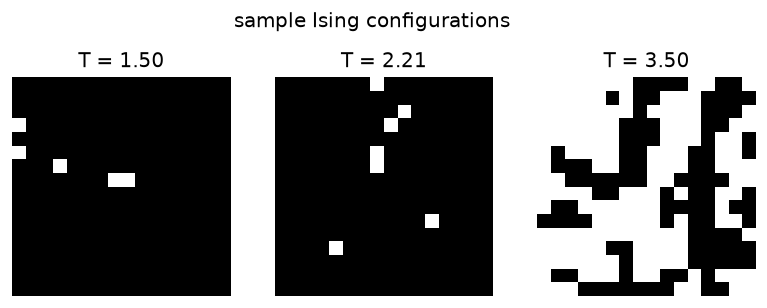

In [101]:
# Show one sample at three representative temperatures.
fig, ax = plt.subplots(1, 3, figsize=(8, 3))
for k, T_show in enumerate([1.5, T_c, 3.5]):
    j = np.argmin(np.abs(temps_perm - T_show))
    ax[k].imshow(configs_perm[j], cmap='gray', vmin=-1, vmax=1)
    ax[k].set_title(f'T = {temps_perm[j]:.2f}')
    ax[k].axis('off')
plt.suptitle('sample Ising configurations')
plt.show()

Train a one-dimensional-bottleneck autoencoder. Because the data is in $\{-1, +1\}$ rather than $[0, 1]$, we use `jnp.tanh` as the decoder's output activation so the reconstructed pixels stay in the right range.

step     0  loss=1.001057
step  1000  loss=0.580836
step  2000  loss=0.614635
step  2999  loss=0.576128


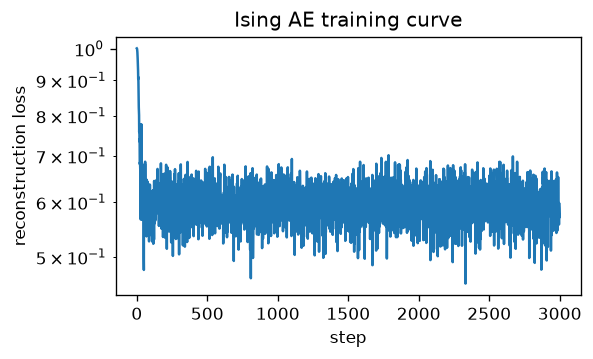

In [102]:
rng = jax.random.key(0)
rng, sub = jax.random.split(rng)
params_ising, losses_ising = train_ae(
    X_ising, latent_dim=1, key=sub,
    hidden=(128, 32), n_steps=3000, batch_size=128, lr=1e-3,
    final_activation=jnp.tanh,
)

plt.figure(figsize=(5, 2.8))
plt.plot(losses_ising)
plt.xlabel('step'); plt.ylabel('reconstruction loss')
plt.yscale('log')
plt.title('Ising AE training curve')
plt.show()

Now the punchline. Encode every configuration through the trained encoder, and plot the resulting one-dimensional latent value against the (known) temperature it was sampled at. For comparison, on the right we plot the *actual* magnetisation per spin &mdash; the textbook order parameter.

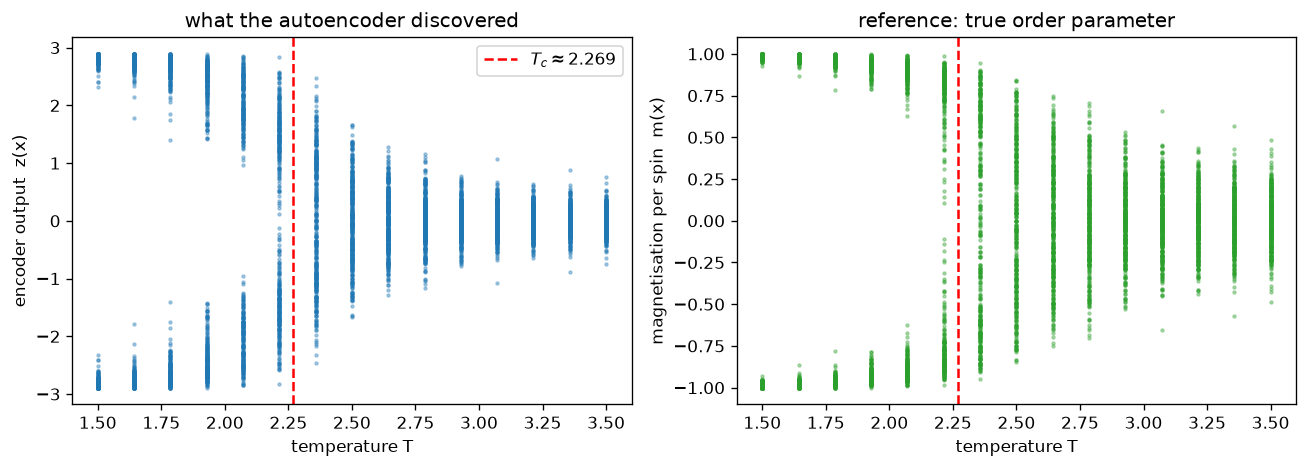

In [ ]:
enc_p, _ = params_ising
z = np.asarray(encoder(enc_p, X_ising)).flatten() # Flatten (2*nT*n_per_T,1)->(2*nT*n_per_T,)
m = X_ising.mean(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(temps_perm, z, s=3, alpha=0.35, color='C0')
ax[0].axvline(T_c, color='red', linestyle='--', label=fr'$T_c \approx {T_c:.3f}$')
ax[0].set_xlabel('temperature T')
ax[0].set_ylabel('encoder output  z(x)')
ax[0].set_title('what the autoencoder discovered')
ax[0].legend()

ax[1].scatter(temps_perm, m, s=3, alpha=0.35, color='C2')
ax[1].axvline(T_c, color='red', linestyle='--')
ax[1].set_xlabel('temperature T')
ax[1].set_ylabel('magnetisation per spin  m(x)')
ax[1].set_title('reference: true order parameter')

plt.tight_layout()
plt.show()

The two plots have the same shape. Below $T_c$ the latent splits into two branches (one for $+m$ configurations, one for $-m$), and above $T_c$ it collapses to a single noisy band around zero. The autoencoder has rediscovered the **magnetisation** as the single most informative degree of freedom, and through it, the location of the phase transition, with no labels and no physics input beyond the Metropolis sampler.

The correspondence between the encoder outout and the magnetisation is even more obvious when plotted against each other, it is a one-to-one mapping.

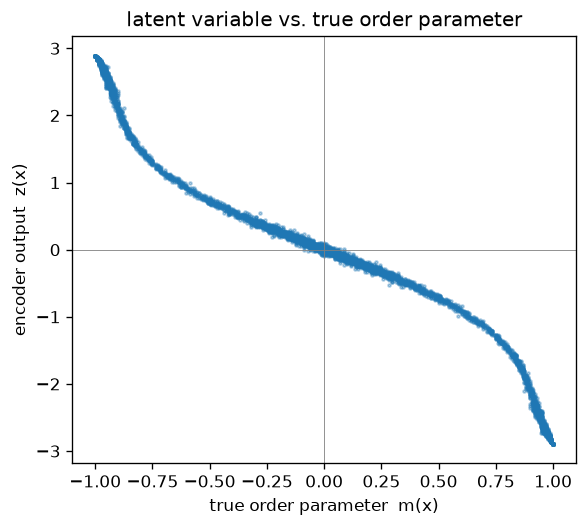

In [104]:
# Direct comparison: encoder output z vs. true order parameter m.
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(m, z, s=3, alpha=0.35, color='C0')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('true order parameter  m(x)')
ax.set_ylabel('encoder output  z(x)')
ax.set_title('latent variable vs. true order parameter')
plt.tight_layout()
plt.show()

---
## 6. Things to try later

1. **Add a rotation factor to the blobs.** Modify `make_aniso_blobs` so each Gaussian also has a random rotation angle $\theta$. There are now five factors. Re-run the capacity sweep, does the transition shift? Try with other feature-rich data.
2. **Does the AE actually learn the full ``latent_dim``-parameter family of mappings?** &sect;3 and &sect;4 with ``IMAGE_WIDTH``$=32$ and try to understand what is going on.
3. **Ising with `latent_dim = 2`.** Repeat &sect;5 with a two-dimensional bottleneck. What does the second latent axis end up encoding? (Hint: think about the energy as a possible second order parameter.)
